In [9]:
from numpy import argsort

from os import listdir
from PIL import Image as PImage

from torch import no_grad

from sklearn.metrics.pairwise import cosine_distances, euclidean_distances

# DEVICE = "cpu"
DEVICE = "mps"
# DEVICE = "cuda"

In [10]:
from transformers import CLIPProcessor, CLIPModel

clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(DEVICE)

In [11]:
from pathlib import Path

IMG_DIR = Path("../generated/real_images").resolve()
fnames = sorted([f.name for f in IMG_DIR.iterdir() if f.name.endswith("_no_bg.png")])

img = PImage.open(IMG_DIR / fnames[0])

img_t = clip_processor(images=img, return_tensors="pt", padding=True).to(DEVICE)

with no_grad():
    clip_embedding = clip_model.get_image_features(**img_t)[0]
    
clip_embedding.shape

torch.Size([768])

In [12]:
img_embeddings = []

for f in fnames:
    img = PImage.open(IMG_DIR / f)  # since IMG_DIR is a Path
    img_t = clip_processor(images=img, return_tensors="pt", padding=True).to(DEVICE)
    with no_grad():
        out = clip_model.get_image_features(**img_t)   # shape: [1, hidden_dim]
        img_embeddings.append(out[0].tolist())         # or out.squeeze(0).tolist()

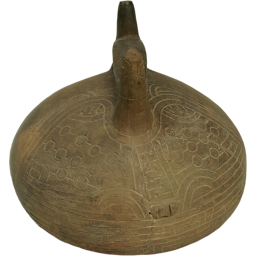

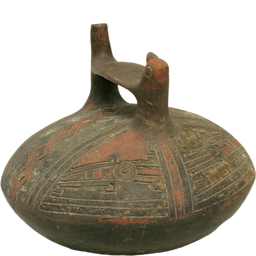

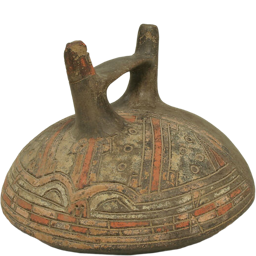

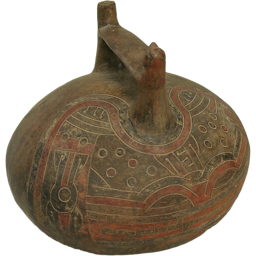

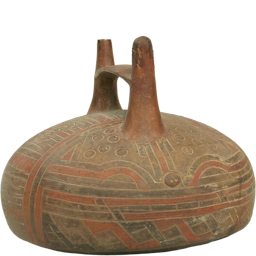

In [28]:
# src_idx = 10
src_idx = 1000
dists = euclidean_distances(img_embeddings)
sorted_idxs = argsort(dists[src_idx])

for idx in sorted_idxs[:5]:
  img = PImage.open(f"{IMG_DIR}/{fnames[idx]}")
  img.thumbnail((256, 256))
  display(img)

In [24]:

txt = "blue and white ceramic"
# txt = "yellow vessel"

txt_t = clip_processor(
    text=txt,
    padding="max_length",
    max_length=64,
    return_tensors="pt"
).to(DEVICE)

with no_grad():
    txt_embedding = clip_model.get_text_features(**txt_t)[0].tolist()
    # or: clip_model.get_text_features(**txt_t).squeeze(0).tolist()

len(txt_embedding)

768

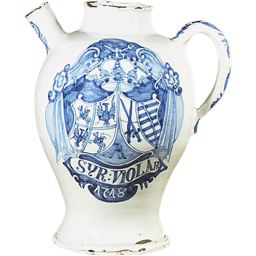

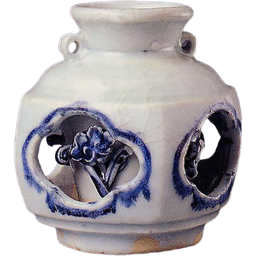

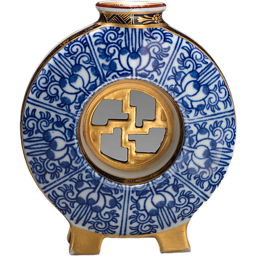

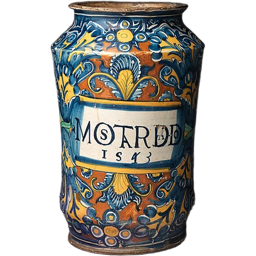

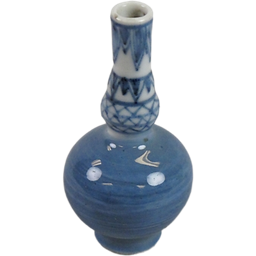

In [25]:
dists = euclidean_distances([txt_embedding], img_embeddings)
sorted_idxs = argsort(dists[0])

for idx in sorted_idxs[:5]:
  img = PImage.open(f"{IMG_DIR}/{fnames[idx]}")
  img.thumbnail((256, 256))
  display(img)